# Thousand Voices of Trauma — Exploratory Data Analysis

Goal: understand the **TV** corpus before using it downstream (labelling, prefix-tree DAGs,
LLM-DAG scoring). This notebook reads the raw files directly so you can see the actual
structure, then summarises content, structure, and the train/test split.

**Kernel:** run this with the `fudge` conda env (it has the project deps + pandas/matplotlib).

**What TV is, in one line:** 500 simulated PTSD clients × 6 Prolonged-Exposure (PE) therapy
phases = 3000 synthetic therapist↔client conversations, each with client/therapist/trauma metadata.
There are **no turn labels** — that's why the labelling pipeline exists.

In [2]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

# Anchor to the project root (the dir containing data/) so this works whether the
# notebook is launched from the repo root or from notebooks/.
ROOT = Path.cwd()
while not (ROOT / "data").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# Point at the ThousandVoicesOfTrauma root (holds conversations/ and metadata/)
TV_DIR   = ROOT / "data/thousand-voices-trauma/ThousandVoicesOfTrauma"
CONV_DIR = TV_DIR / "conversations"
META_DIR = TV_DIR / "metadata"
assert CONV_DIR.is_dir() and META_DIR.is_dir(), f"check TV_DIR (cwd={Path.cwd()}): {TV_DIR}"

PHASE_ORDER = ["P5", "P6", "P7", "P8", "P10", "P11"]
PHASE_NAMES = {"P5": "Orientation", "P6": "SUDS monitoring", "P7": "Reinforcing exposure",
               "P8": "Eliciting thoughts", "P10": "Full imaginal exposure", "P11": "Processing"}
print("conversation files:", len(list(CONV_DIR.glob("*_conversation.json"))))

conversation files: 3000


## 1. Load everything into one table

One row per conversation. We parse `full_conversation` (a list of `"Therapist: ..."` /
`"Client: ..."` strings) into turns, and pull the metadata profiles. `convs_text` keeps the
parsed turns so we can read real conversations later.

In [3]:
def parse_turns(full_conversation):
    turns = []
    for line in full_conversation:
        if ":" not in line:
            continue
        speaker, text = line.split(":", 1)
        sp = speaker.strip()
        if sp not in ("Therapist", "Client"):
            continue
        t = text.strip()
        if t:
            turns.append((sp, t))
    return turns

rows, convs_text = [], {}
for cf in sorted(CONV_DIR.glob("*_conversation.json")):
    stem = cf.stem.removesuffix("_conversation")      # e.g. "100_P6"
    subj, phase = stem.split("_P", 1)
    phase = "P" + phase
    mf = META_DIR / f"{stem}_metadata.json"
    if not mf.exists():
        continue
    conv = json.load(open(cf, encoding="utf-8"))
    meta = json.load(open(mf, encoding="utf-8"))
    turns = parse_turns(conv.get("full_conversation", []))
    convs_text[stem] = turns

    ti = meta.get("trauma_info", {})
    cp = meta.get("client_profile", {})
    tp = meta.get("therapist_profile", {})
    ther_words = [len(t.split()) for s, t in turns if s == "Therapist"]
    cli_words  = [len(t.split()) for s, t in turns if s == "Client"]
    rows.append(dict(
        stem=stem, subject=int(subj), phase=phase, phase_name=PHASE_NAMES.get(phase, phase),
        trauma_type=ti.get("type", ""), session_topic=ti.get("session_topic", ""),
        client_age=cp.get("age"), client_gender=cp.get("gender"),
        co_occurring=cp.get("co_occurring_condition"),
        n_behaviors=len(cp.get("exhibited_behaviors", []) or []),
        therapist_gender=tp.get("gender"),
        n_turns=len(turns),
        n_therapist=len(ther_words), n_client=len(cli_words),
        ther_words=np.mean(ther_words) if ther_words else 0.0,
        cli_words=np.mean(cli_words) if cli_words else 0.0,
    ))

df = pd.DataFrame(rows)
print("table shape:", df.shape)
df.head()

table shape: (3000, 16)


,stem,subject,phase,phase_name,trauma_type,session_topic,client_age,client_gender,co_occurring,n_behaviors,therapist_gender,n_turns,n_therapist,n_client,ther_words,cli_words
0,100_P10,100,P10,Full imaginal exposure,witnessing violence,police brutality,32,male,Depression,5,female,61,31,30,7.677419,28.933333
1,100_P11,100,P11,Processing,witnessing violence,police brutality,32,male,Depression,5,female,24,12,12,8.000000,41.000000
2,100_P5,100,P5,Orientation,witnessing violence,police brutality,32,male,Depression,5,female,19,10,9,14.600000,38.666667
3,100_P6,100,P6,SUDS monitoring,witnessing violence,police brutality,32,male,Depression,5,female,35,18,17,8.222222,25.000000
4,100_P7,100,P7,Reinforcing exposure,witnessing violence,police brutality,32,male,Depression,5,female,41,21,20,7.904762,29.450000


## 2. Dataset overview

In [4]:
print("Conversations :", len(df))
print("Subjects      :", df.subject.nunique())
print("Phases        :", df.phase.nunique(), sorted(df.phase.unique(), key=lambda p: PHASE_ORDER.index(p)))
print("Trauma types  :", df.trauma_type.nunique())
print("Session topics:", df.session_topic.nunique())
print()
print("conversations per phase:")
print(df.phase.value_counts().reindex(PHASE_ORDER))
print()
# data integrity: does every subject have all 6 phases?
per_subj = df.groupby("subject").phase.nunique().value_counts().to_dict()
print("phases-per-subject distribution (expect {6: 500}):", per_subj)

Conversations : 3000
Subjects      : 500
Phases        : 6 ['P5', 'P6', 'P7', 'P8', 'P10', 'P11']
Trauma types  : 13
Session topics: 23

conversations per phase:
phase
P5     500
P6     500
P7     500
P8     500
P10    500
P11    500
Name: count, dtype: int64

phases-per-subject distribution (expect {6: 500}): {6: 500}


## 3. Who are the clients? (metadata)

TV's metadata is the richest part — trauma category, session topic, and a synthetic client profile.
The `trauma_type` (13 classes) and `session_topic` (23 classes) are what the discrimination
experiments stratify on.

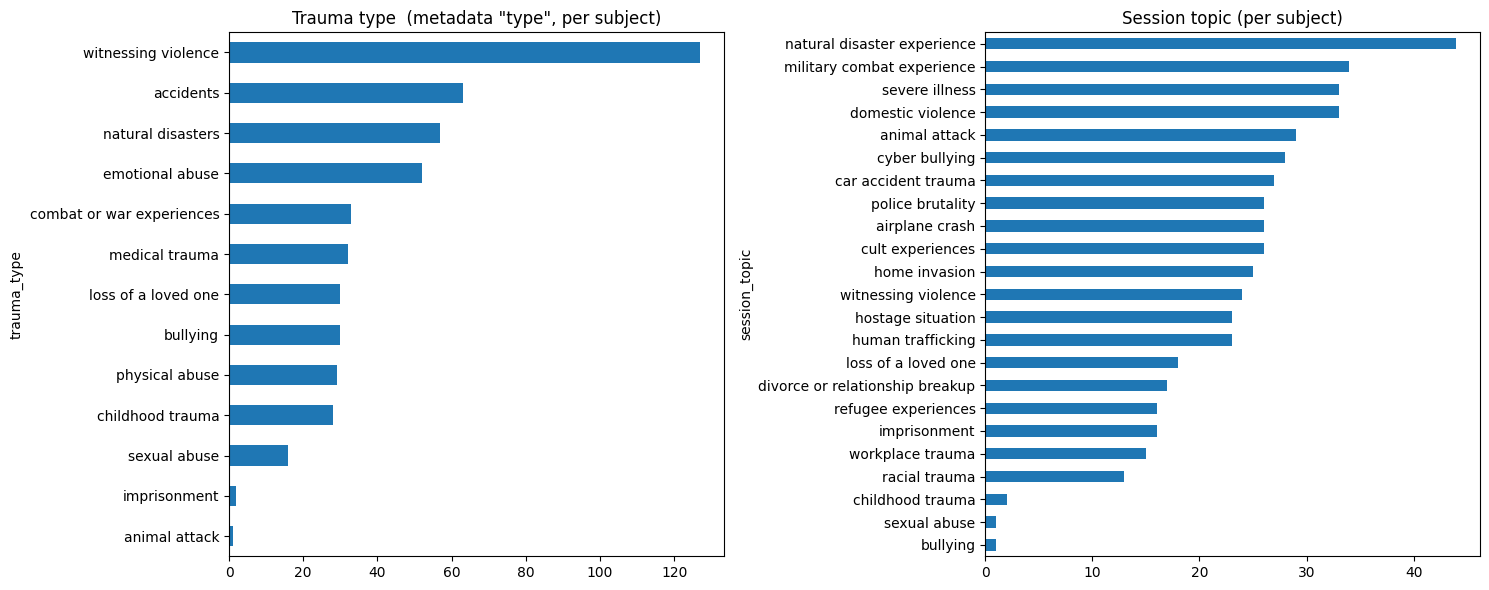

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
df.drop_duplicates("subject").trauma_type.value_counts().plot.barh(ax=ax[0])
ax[0].set_title('Trauma type  (metadata "type", per subject)'); ax[0].invert_yaxis()
df.drop_duplicates("subject").session_topic.value_counts().plot.barh(ax=ax[1])
ax[1].set_title("Session topic (per subject)"); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

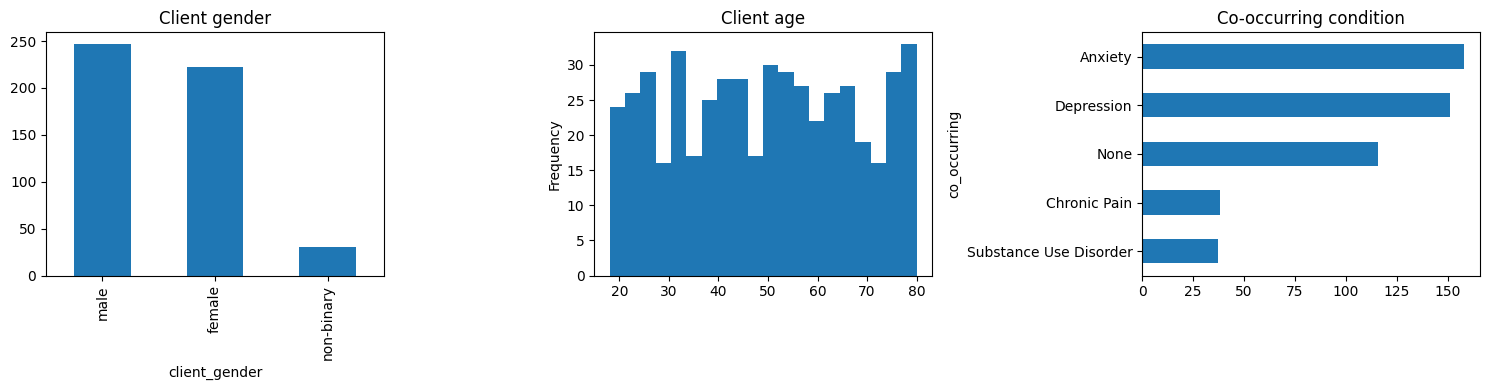

trauma_type x is independent of phase (same client across phases) — confirm:
{'P5': 13, 'P6': 13, 'P7': 13, 'P8': 13, 'P10': 13, 'P11': 13}


In [6]:
subj_df = df.drop_duplicates("subject")
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
subj_df.client_gender.value_counts().plot.bar(ax=ax[0], title="Client gender")
subj_df.client_age.dropna().plot.hist(bins=20, ax=ax[1], title="Client age")
subj_df.co_occurring.value_counts().plot.barh(ax=ax[2], title="Co-occurring condition")
ax[2].invert_yaxis()
plt.tight_layout(); plt.show()
print("trauma_type x is independent of phase (same client across phases) — confirm:")
print(df.groupby("phase").trauma_type.nunique().reindex(PHASE_ORDER).to_dict())

## 4. Conversation structure by phase

How long are conversations, and how do therapist vs client contributions differ across the six
PE phases? This is the structural signal the prefix-tree DAGs and FuDGE rely on.

In [7]:
g = df.groupby("phase").agg(
    n=("n_turns", "size"),
    mean_turns=("n_turns", "mean"),
    median_turns=("n_turns", "median"),
    mean_ther_turns=("n_therapist", "mean"),
    mean_cli_turns=("n_client", "mean"),
    ther_words_per_turn=("ther_words", "mean"),
    cli_words_per_turn=("cli_words", "mean"),
).reindex(PHASE_ORDER).round(1)
g.insert(0, "phase_name", [PHASE_NAMES[p] for p in g.index])
g

,phase_name,n,mean_turns,median_turns,mean_ther_turns,mean_cli_turns,ther_words_per_turn,cli_words_per_turn
phase,,,,,,,,
P5,Orientation,500,20.6,20.0,10.6,10.0,13.0,34.6
P6,SUDS monitoring,500,33.3,33.0,17.1,16.2,7.7,27.7
P7,Reinforcing exposure,500,29.5,29.0,15.2,14.3,8.4,44.8
P8,Eliciting thoughts,500,30.9,31.0,15.8,15.1,9.7,55.0
P10,Full imaginal exposure,500,63.9,63.0,32.4,31.5,10.0,29.5
P11,Processing,500,24.6,24.0,12.5,12.1,9.3,42.9


C:\Users\ratne\AppData\Local\Temp\ipykernel_34552\32394763.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([df[df.phase == p].n_turns.values for p in PHASE_ORDER], labels=PHASE_ORDER, showfliers=False)


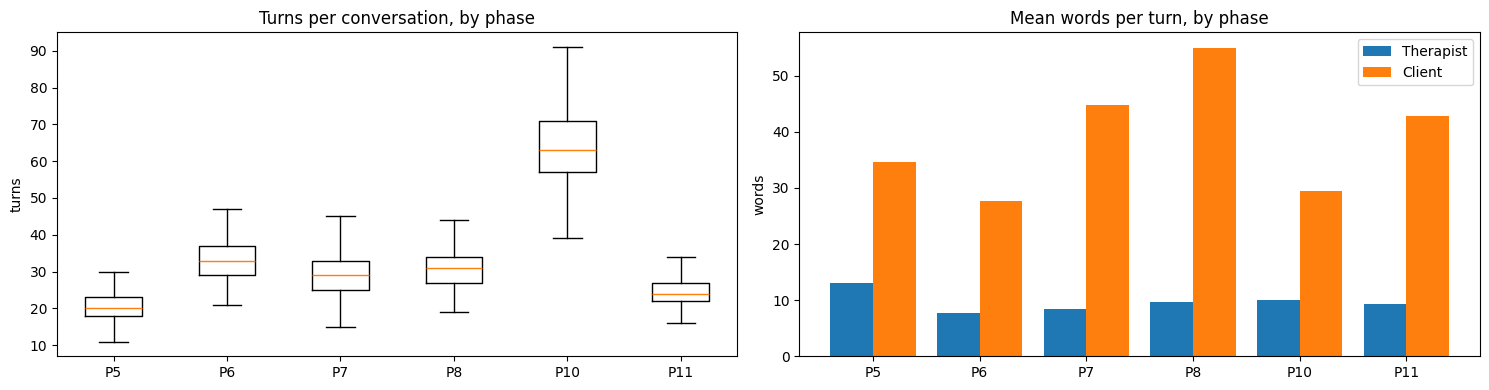

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].boxplot([df[df.phase == p].n_turns.values for p in PHASE_ORDER], labels=PHASE_ORDER, showfliers=False)
ax[0].set_title("Turns per conversation, by phase"); ax[0].set_ylabel("turns")

x = np.arange(len(PHASE_ORDER))
ax[1].bar(x - 0.2, [df[df.phase == p].ther_words.mean() for p in PHASE_ORDER], width=0.4, label="Therapist")
ax[1].bar(x + 0.2, [df[df.phase == p].cli_words.mean()  for p in PHASE_ORDER], width=0.4, label="Client")
ax[1].set_xticks(x); ax[1].set_xticklabels(PHASE_ORDER)
ax[1].set_title("Mean words per turn, by phase"); ax[1].set_ylabel("words"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Phase fingerprint — are the phases actually distinguishable?

This is the crux for the whole project: if phases differ only by label, no metric can tell them
apart. We check the presence of phase-characteristic surface cues (keyword/regex) in each
conversation, then look at the fraction per phase. Clear diagonal-ish structure = phases carry
real, separable signal.

,SUDS / rating,close eyes/present,grounding,breathing,continue narrative,thoughts/beliefs,wrap up / next time
phase,,,,,,,
P5,2,34,23,58,3,2,9
P6,100,73,7,100,97,4,30
P7,1,10,3,89,97,4,71
P8,4,0,23,87,13,78,80
P10,100,85,55,100,99,52,72
P11,4,0,19,60,43,6,76


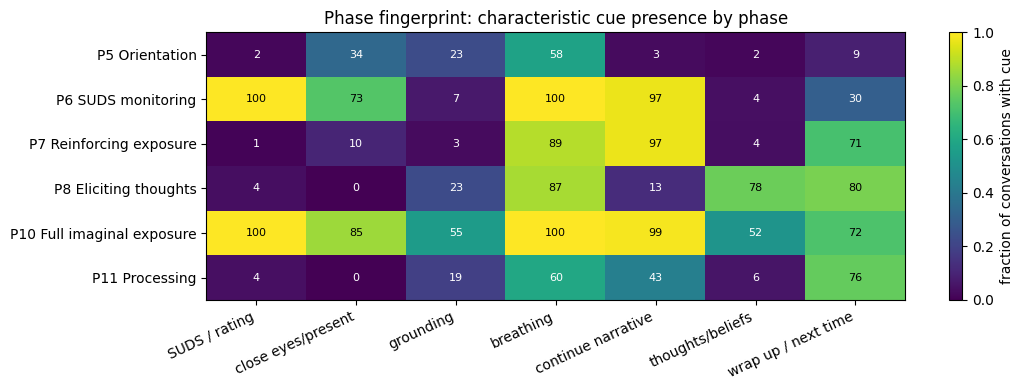

In [9]:
KEYWORDS = {
    "SUDS / rating":        r"\bsuds\b|distress level|0 to 100|scale of|rate (your|the)",
    "close eyes/present":   r"close your eyes|present tense|as if it.?s happening|bring yourself back",
    "grounding":            r"feel your feet|look around|name .{0,12}things|grounding|five senses|present moment",
    "breathing":            r"\bbreath|inhale|exhale",
    "continue narrative":   r"what happens next|keep going|go on|continue (with|the)",
    "thoughts/beliefs":     r"what (were|was) you thinking|going through your mind|what does that (say|mean)|belief",
    "wrap up / next time":  r"next session|wrap up|for today|end (of|our) (the )?session|see you",
}
recs = []
for p in PHASE_ORDER:
    sub = df[df.phase == p]
    texts = [" ".join(t for _, t in convs_text[s]).lower() for s in sub.stem]
    rec = {"phase": p}
    for name, pat in KEYWORDS.items():
        rec[name] = float(np.mean([bool(re.search(pat, tx)) for tx in texts]))
    recs.append(rec)
kdf = pd.DataFrame(recs).set_index("phase")
display((kdf * 100).round(0).astype(int))   # % of conversations containing each cue

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(kdf.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(kdf.columns))); ax.set_xticklabels(kdf.columns, rotation=25, ha="right")
ax.set_yticks(range(len(kdf.index)));   ax.set_yticklabels([f"{p} {PHASE_NAMES[p]}" for p in kdf.index])
for i in range(kdf.shape[0]):
    for j in range(kdf.shape[1]):
        ax.text(j, i, f"{kdf.values[i, j]*100:.0f}", ha="center", va="center",
                color="w" if kdf.values[i, j] < 0.6 else "k", fontsize=8)
plt.colorbar(im, label="fraction of conversations with cue")
ax.set_title("Phase fingerprint: characteristic cue presence by phase"); plt.tight_layout(); plt.show()

## 6. Read real conversations

Numbers only get you so far — read actual data. Below: the opening of one conversation per phase
for the same client, so you can see how the phases differ in practice.

In [10]:
def show_conversation(stem, max_turns=10):
    turns = convs_text.get(stem)
    if not turns:
        print(f"[{stem} not found]"); return
    meta = json.load(open(META_DIR / f"{stem}_metadata.json", encoding="utf-8"))
    ti, phase = meta["trauma_info"], "P" + stem.split("_P", 1)[1]
    print(f"=== {stem}  |  {phase} {PHASE_NAMES.get(phase,'')}  |  "
          f"{ti['type']} / {ti['session_topic']}  |  {len(turns)} turns ===")
    for i, (sp, t) in enumerate(turns):
        if i >= max_turns:
            print(f"   ... (+{len(turns)-max_turns} more turns)"); break
        tag = "T" if sp == "Therapist" else "C"
        print(f"  {tag}: {t}")
    print()

subj = int(df.subject.min())
for p in PHASE_ORDER:
    show_conversation(f"{subj}_{p}", max_turns=8)

=== 1_P5  |  P5 Orientation  |  accidents / airplane crash  |  19 turns ===
  T: Mr. Lee, today we'll be starting imaginal exposure. How are you feeling about that?
  C: I'm a bit nervous, to be honest. I've been thinking about it since our last session. The idea of revisiting that airplane crash... it's not easy. I've spent years trying to forget it. But I trust you, doctor. Can you tell me more about what we'll be doing?
  T: Of course. It's natural to feel nervous. Can you share more about your concerns?
  C: Well, I'm worried about how I'll react. What if I panic? Or what if I can't handle it and break down? I've always prided myself on being strong, you know. My wife depends on me, and I don't want to let her down by falling apart here.
  T: Your concerns are valid. How have you managed difficult emotions in the past?
  C: I usually try to stay busy. I'll work in the garden or help my wife with household chores. Sometimes I'll go for a walk. But this feels different. It's like I'm

## 7. The train/test split (TV_v1)

The locked, versioned split used everywhere downstream. 70/30, stratified by phase and balanced by
trauma type within phase; two tiny trauma types dropped. Test data is never reused as a DAG-building
input.

version : TV_v1 | stratum: phase / type (within phase)
train_frac: 0.7 | seed: 20260530
dropped types: ['animal attack', 'imprisonment'] | dropped dialogues: 18
train total: 2082 | test total: 900


,train,test
P5,347,150
P6,347,150
P7,347,150
P8,347,150
P10,347,150
P11,347,150


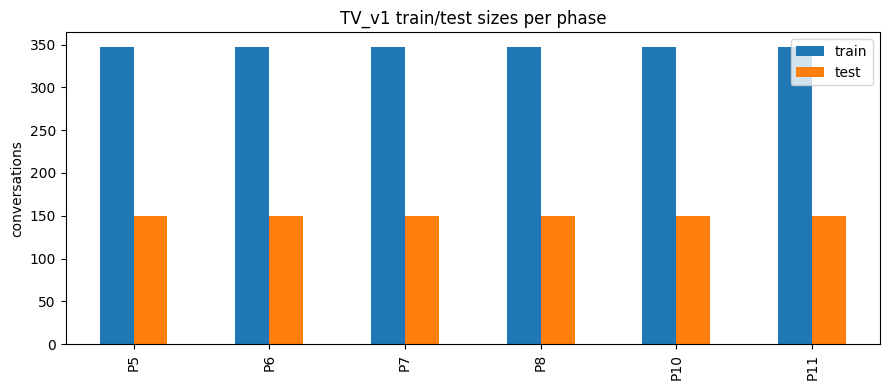

In [11]:
split = json.load(open(ROOT / "data/splits/TV_v1.json", encoding="utf-8"))
print("version :", split["version"], "| stratum:", split["stratum"], "/", split["sub_stratum"])
print("train_frac:", split["train_frac"], "| seed:", split["seed"])
print("dropped types:", split["drop_types"], "| dropped dialogues:", split["n_dropped_dialogues"])
print("train total:", split["n_train_total"], "| test total:", split["n_test_total"])

sp = pd.DataFrame({p: {"train": len(v["train"]), "test": len(v["test"])}
                   for p, v in split["splits"].items()}).T.reindex(PHASE_ORDER)
display(sp)
sp.plot.bar(figsize=(9, 4), title="TV_v1 train/test sizes per phase")
plt.ylabel("conversations"); plt.tight_layout(); plt.show()

## 8. Sanity check via the project loader

Everything above read raw JSON. The pipeline uses `load_thousand_voices_dialogues`, which maps
Therapist→`agent`, Client→`user` and assigns `dialogue_id = subject*100 + phase`. Quick confirmation
it returns what we expect.

In [12]:
import sys
sys.path.insert(0, str(ROOT / "src"))
from fudge.data_loader import load_thousand_voices_dialogues

convs = load_thousand_voices_dialogues(TV_DIR, task_field="type", require_phases=("P6",))
c = convs[0]
print("loaded", len(convs), "P6 conversations via the project loader")
print("dialogue_id:", c.dialogue_id, "(= subject*100 + phase)")
print("task (trauma_type):", c.task)
print("n utterances:", len(c.utterances))
print("first:", c.utterances[0].actor, "->", c.utterances[0].text[:90])

loaded 500 P6 conversations via the project loader
dialogue_id: 10006 (= subject*100 + phase)
task (trauma_type): witnessing violence
n utterances: 35
first: agent -> Alright, let's begin our imaginal exposure exercise. Remember, I'll ask for your SUDS rati


## Takeaways

- **3000 conversations** = 500 clients × 6 PE phases (P5, P6, P7, P8, P10, P11), each ~tens of turns,
  therapist-led.
- **No turn labels** — labelling (P5/P6/P7 done so far) is required before prefix-tree DAGs.
- **Metadata is rich**: 13 trauma types, 23 session topics, client/therapist profiles — the basis for
  stratified splits and for slicing FuDGE results.
- **Phase fingerprint** (§5) shows whether the six phases carry separable surface signal — the
  premise behind the entire FuDGE discrimination validation. Read that heatmap critically: weak
  separation there would predict weak FuDGE discrimination.
- This is the corpus the LLM-generated DAGs are meant to model **per phase** — directly relevant to
  the phase-conditioning issue flagged in the DAG audit.